In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr
from scipy.stats import norm
from datetime import datetime
import matplotlib.ticker as mtick

Файлы:

1)  **olist_customers_dataset.csv** — таблица с уникальными идентификаторами пользователей
customer_id — позаказный идентификатор пользователя

customer_unique_id — уникальный идентификатор пользователя (аналог номера паспорта)

customer_zip_code_prefix — почтовый индекс пользователя

customer_city — город доставки пользователя

customer_state — штат доставки пользователя

2) **olist_orders_dataset.csv **—  таблица заказов
order_id — уникальный идентификатор заказа (номер чека)

customer_id — позаказный идентификатор пользователя

order_status — статус заказа

order_purchase_timestamp — время создания заказа

order_approved_at — время подтверждения оплаты заказа

order_delivered_carrier_date — время передачи заказа в логистическую службу

order_delivered_customer_date — время доставки заказа

order_estimated_delivery_date — обещанная дата доставки

3) **olist_order_items_dataset.csv** — товарные позиции, входящие в заказы
order_id — уникальный идентификатор заказа (номер чека)

order_item_id — идентификатор товара внутри одного заказа

product_id — ид товара (аналог штрихкода)

seller_id — ид производителя товара

shipping_limit_date — максимальная дата доставки продавцом для передачи заказа партнеру по логистике

price — цена за единицу товара

freight_value — вес товара

Пример структуры данных можно визуализировать по order_id == 00143d0f86d6fbd9f9b38ab440ac16f5

Уникальные статусы заказов в таблице olist_orders_dataset:

created — создан;
approved — подтверждён;
invoiced — выставлен счёт;
processing — в процессе сборки заказа;
shipped — отгружён со склада;
delivered — доставлен пользователю;
unavailable — заказ отменён по причине недоступности товара;;
canceled — отменён.

In [2]:
c=pd.read_csv('/content/olist_customers_dataset.csv')
oi=pd.read_csv('/content/olist_order_items_dataset.csv')
o=pd.read_csv('/content/olist_orders_dataset.csv')

Задача 1. Оценить месячный retention в оформление заказа с помощью когортного анализа.

На первом этапе вы решили посмотреть на метрики маркетплейса и на возвращаемость клиента в продукт.

Для этого вам нужно:

Оценить месячный retention в оформление заказа с помощью когортного анализа, так как важно, чтобы клиенты возвращались в маркетплейс для совершения больших покупок.

В рамках исследования необходимо:

Исследовать датасет и определить, какой вид заказа будет учитываться в retention
Построить месячный retention
Проанализировать, чему равен медианный retention 1-го месяца (т.е. взять retention 1-ого месяца для всех когорт и посчитать по этим числам медиану)
Найти когорту с самым высоким retention на 3-й месяц.
Проиллюстрировать результаты релевантной визуализацией, удобной для восприятия.

In [3]:
c.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [4]:
oi.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [5]:
o.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [6]:
df_o_c = pd.merge(o, c, on='customer_id', how='inner')
date_columns = ['order_purchase_timestamp', 'order_approved_at',
                'order_delivered_carrier_date', 'order_delivered_customer_date',
                'order_estimated_delivery_date']

df_o_c[date_columns] = df_o_c[date_columns].apply(pd.to_datetime, errors='coerce')
df_o_c

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP
...,...,...,...,...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,6359f309b166b0196dbf7ad2ac62bb5a,12209,sao jose dos campos,SP
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,da62f9e57a76d978d02ab5362c509660,11722,praia grande,SP
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,737520a9aad80b3fbbdad19b66b37b30,45920,nova vicosa,BA
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,5097a5312c8b157bb7be58ae360ef43c,28685,japuiba,RJ


In [7]:
# #месячный retention
# def calculate_monthly_retention(df: pd.DataFrame, months: list) -> list:
#     # Находим дату первой покупки для каждого клиента
#     start_date = df.groupby('customer_unique_id')['order_purchase_timestamp'].min().rename('start_date')
#     df = pd.merge(df, start_date, left_on='customer_unique_id', right_index=True)

#     # Рассчитываем количество месяцев от первой покупки
#     df['month'] = ((df['order_purchase_timestamp'] - df['start_date']).dt.days / 30).astype(int)
#     total_users = df['customer_unique_id'].nunique()

#     # Рассчитываем retention для каждого месяца
#     monthly_retention = []

#     for month in months:
#         users_in_month = df[df['month'] == month]['customer_unique_id'].nunique()
#         retention_rate = (users_in_month / total_users) * 100
#         monthly_retention.append(retention_rate)

#     return monthly_retention

In [8]:
# Смотрим распределение заказов по статусам
status_analysis=o['order_status'].value_counts().reset_index()
status_analysis.columns = ['status','count']
status_analysis['%'] =(status_analysis['count'] / len(o)) * 100
print("Распределение заказов по статусам:")
print(status_analysis.to_string(index=False))

# будем учитывать только доставленные заказы, которые формируют позитивный опыт клиента

df_delivered=df_o_c[df_o_c['order_status']=='delivered'].copy()
print(f"Отобрано доставленных заказов: {len(df_delivered)}")

Распределение заказов по статусам:
     status  count         %
  delivered  96478 97.020344
    shipped   1107  1.113223
   canceled    625  0.628513
unavailable    609  0.612423
   invoiced    314  0.315765
 processing    301  0.302692
    created      5  0.005028
   approved      2  0.002011
Отобрано доставленных заказов: 96478


In [9]:
#для когортного анализа

unique_customers=df_delivered['customer_unique_id'].nunique()
print(f"Уникальных клиентов: {unique_customers}")
print(f"Период данных: с {df_delivered['order_purchase_timestamp'].min()} по {df_delivered['order_purchase_timestamp'].max()}")

#находим дату первой покупки для каждого клиента
first_purchase=df_delivered.groupby('customer_unique_id')['order_purchase_timestamp'].min().reset_index()
first_purchase.columns=['customer_unique_id', 'first_purchase_date']
first_purchase['cohort_month'] = first_purchase['first_purchase_date'].dt.to_period('M')
print(f"Всего когорт: {first_purchase['cohort_month'].nunique()}")
print(f"Диапазон когорт: с {first_purchase['cohort_month'].min()} по {first_purchase['cohort_month'].max()}")

df_cohort=pd.merge(df_delivered, first_purchase, on='customer_unique_id', how='left')
df_cohort['order_month']= df_cohort['order_purchase_timestamp'].dt.to_period('M')
df_cohort['cohort_index']= (df_cohort['order_month'] - df_cohort['cohort_month']).apply(lambda x: x.n)

#убираем записи с некорректным индексом
df_cohort = df_cohort.dropna(subset=['cohort_index'])
df_cohort['cohort_index'] = df_cohort['cohort_index'].astype(int)

print(f"Диапазон индексов когорт: от {df_cohort['cohort_index'].min()} до {df_cohort['cohort_index'].max()}")

Уникальных клиентов: 93358
Период данных: с 2016-09-15 12:16:38 по 2018-08-29 15:00:37
Всего когорт: 23
Диапазон когорт: с 2016-09 по 2018-08
Диапазон индексов когорт: от 0 до 20


In [10]:
cohort_data=df_cohort.groupby(['cohort_month', 'cohort_index'])['customer_unique_id'].nunique().reset_index()
cohort_pivot = cohort_data.pivot_table(
    index='cohort_month', columns='cohort_index', values='customer_unique_id',
    fill_value=0)
cohort_size = cohort_pivot[0]

#retention в процентах
cohort_retention = cohort_pivot.divide(cohort_size, axis=0)*100

print(cohort_retention.head().round(2))

cohort_index     0       1     2     3     4     5     6     7     8     9   \
cohort_month                                                                  
2016-09       100.0    0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00   
2016-10       100.0    0.00  0.00  0.00  0.00  0.00  0.38  0.00  0.00  0.38   
2016-12       100.0  100.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00   
2017-01       100.0    0.28  0.28  0.14  0.42  0.14  0.42  0.14  0.14  0.00   
2017-02       100.0    0.18  0.31  0.12  0.43  0.12  0.25  0.18  0.12  0.18   

cohort_index    10    11    12    13    14    15    16    17    19    20  
cohort_month                                                              
2016-09       0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  
2016-10       0.00  0.38  0.00  0.38  0.00  0.38  0.00  0.38  0.76  0.76  
2016-12       0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  
2017-01       0.42  0.14  0.70  0.42  0.14  0.14  0.28  0.42  0.14  0.0

In [11]:
#анализ медианного retention 1-го месяца
if 1 in cohort_retention.columns:
    # Получаем все значения retention для 1-го месяца
    retention_month1=cohort_retention[1].dropna()

    median_retention_month1=retention_month1.median()
    mean_retention_month1=retention_month1.mean()
    min_retention_month1=retention_month1.min()
    max_retention_month1=retention_month1.max()

    print(f"Статистика retention 1-го месяца:")
    print(f"Медиана: {median_retention_month1:.2f}%")
    print(f"Среднее: {mean_retention_month1:.2f}%")
    print(f"Минимум: {min_retention_month1:.2f}%")
    print(f"Максимум: {max_retention_month1:.2f}%")
    print(f"Количество когорт: {len(retention_month1)}")


    print("Распределение retention 1го месяца по когортам:")
    print(retention_month1.sort_values(ascending=False).round(2))


Статистика retention 1-го месяца:
Медиана: 0.46%
Среднее: 4.74%
Минимум: 0.00%
Максимум: 100.00%
Количество когорт: 23
Распределение retention 1го месяца по когортам:
cohort_month
2016-12    100.00
2017-10      0.72
2017-09      0.70
2017-08      0.69
2017-04      0.62
2018-04      0.59
2017-11      0.57
2017-07      0.53
2018-05      0.52
2018-07      0.52
2017-06      0.49
2017-05      0.46
2017-03      0.44
2018-06      0.43
2018-03      0.40
2018-02      0.35
2018-01      0.34
2017-01      0.28
2017-12      0.21
2017-02      0.18
2016-10      0.00
2016-09      0.00
2018-08      0.00
Freq: M, Name: 1, dtype: float64


In [12]:
# когорта с самым высоким  retention 3-го месяца

if 3 in cohort_retention.columns and not cohort_retention[3].dropna().empty:
    best = cohort_retention[3].dropna()
    print(f"Когорта с самым высоким  retention 3-го месяца: {best.idxmax()} ({best.max():.2f}%)")

Когорта с самым высоким  retention 3-го месяца: 2017-06 (0.43%)


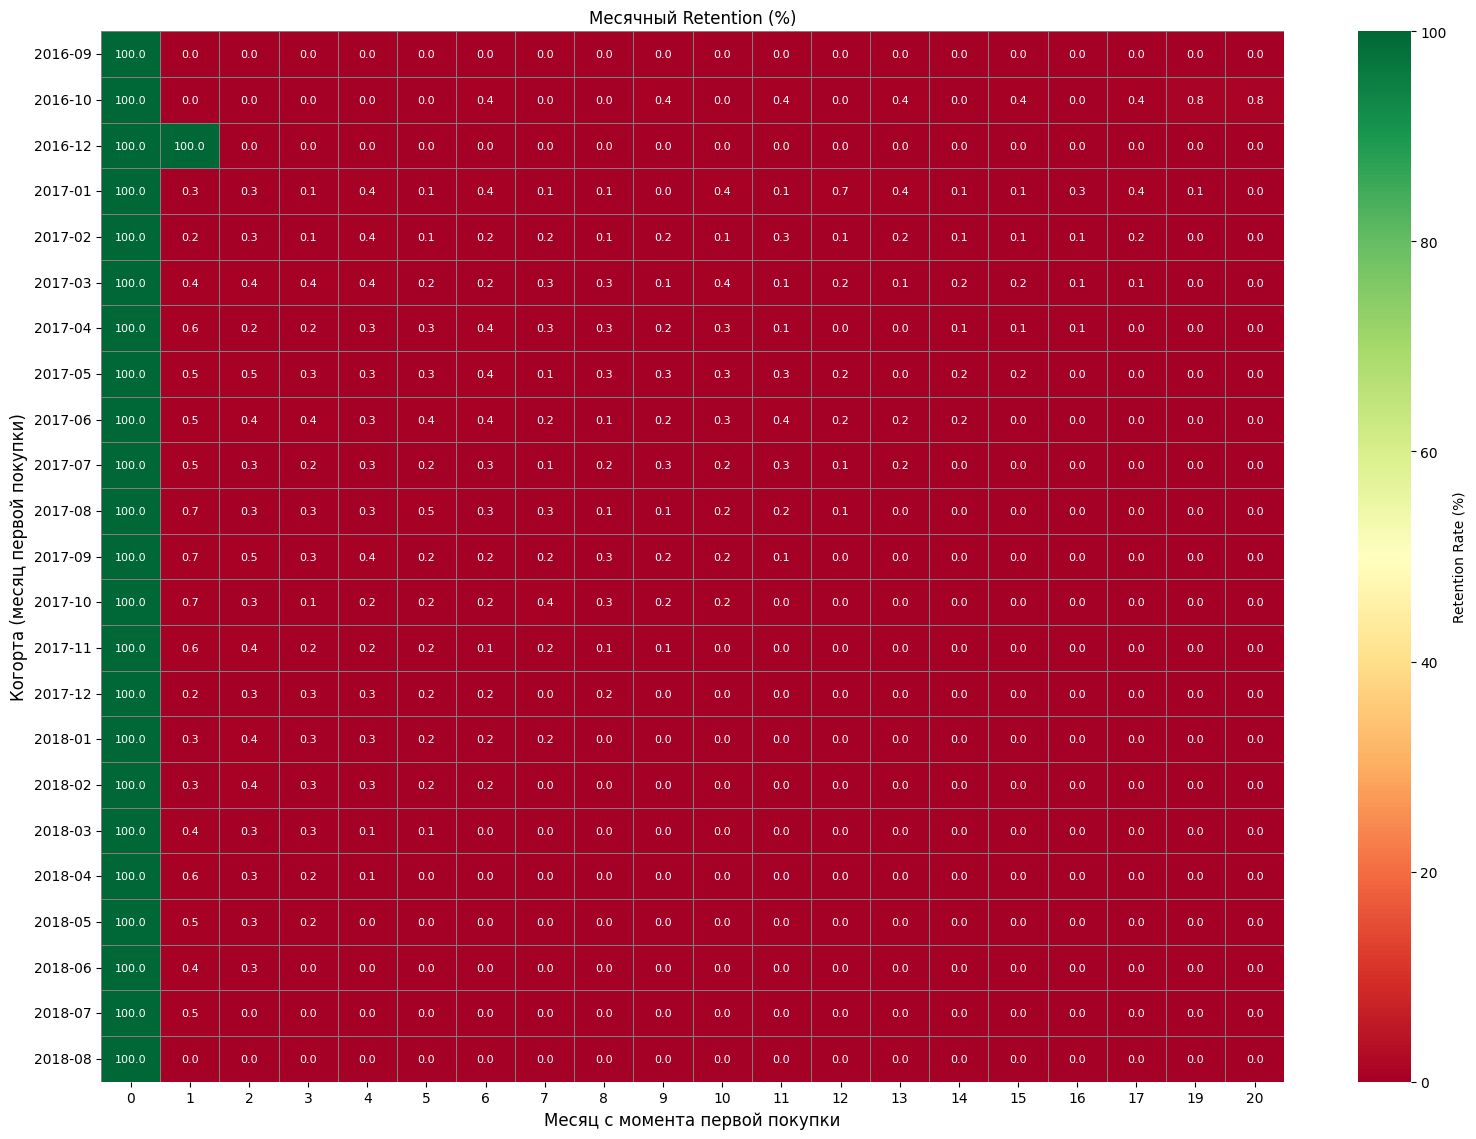

In [13]:
plt.figure(figsize=(max(16, cohort_retention.shape[1] * 0.8),
                   max(10, cohort_retention.shape[0] * 0.5)))
sns.heatmap(cohort_retention.round(1),
            annot=True,
            fmt='.1f',
            cmap='RdYlGn',
            linewidths=0.5,
            linecolor='gray',
            cbar_kws={'label': 'Retention Rate (%)'},
            annot_kws={'size': 8})

plt.title('Месячный Retention (%)')
plt.xlabel('Месяц с момента первой покупки', fontsize=12)
plt.ylabel('Когорта (месяц первой покупки)', fontsize=12)
plt.tight_layout()
plt.show()


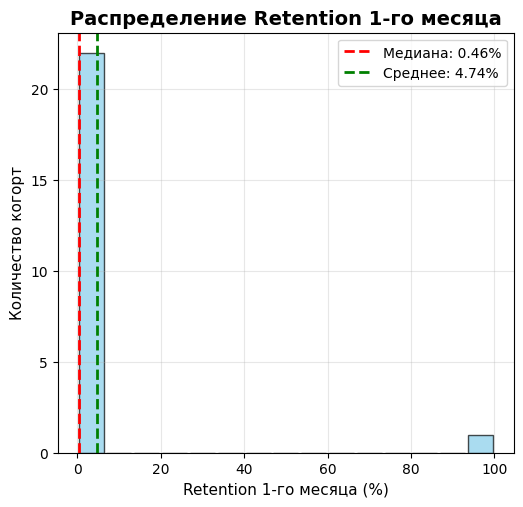

In [14]:
#распределение retention 1-го месяца
fig=plt.figure(figsize=(20, 12))
ax1=plt.subplot(2, 3, 4)
if retention_month1 is not None and len(retention_month1) > 0:
    ax1.hist(retention_month1, bins=15, edgecolor='black', alpha=0.7,
             color='skyblue', rwidth=0.9)
    ax1.axvline(median_retention_month1, color='red', linestyle='--', linewidth=2,
                label=f'Медиана: {median_retention_month1:.2f}%')
    ax1.axvline(mean_retention_month1, color='green', linestyle='--', linewidth=2,
                label=f'Среднее: {mean_retention_month1:.2f}%')
    ax1.set_title('Распределение Retention 1-го месяца', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Retention 1-го месяца (%)', fontsize=11)
    ax1.set_ylabel('Количество когорт', fontsize=11)
    ax1.legend()
    ax1.grid(True, alpha=0.3)



Когорта с самым высоким retention на 3-й месяц: 2017-06 (0.43%)


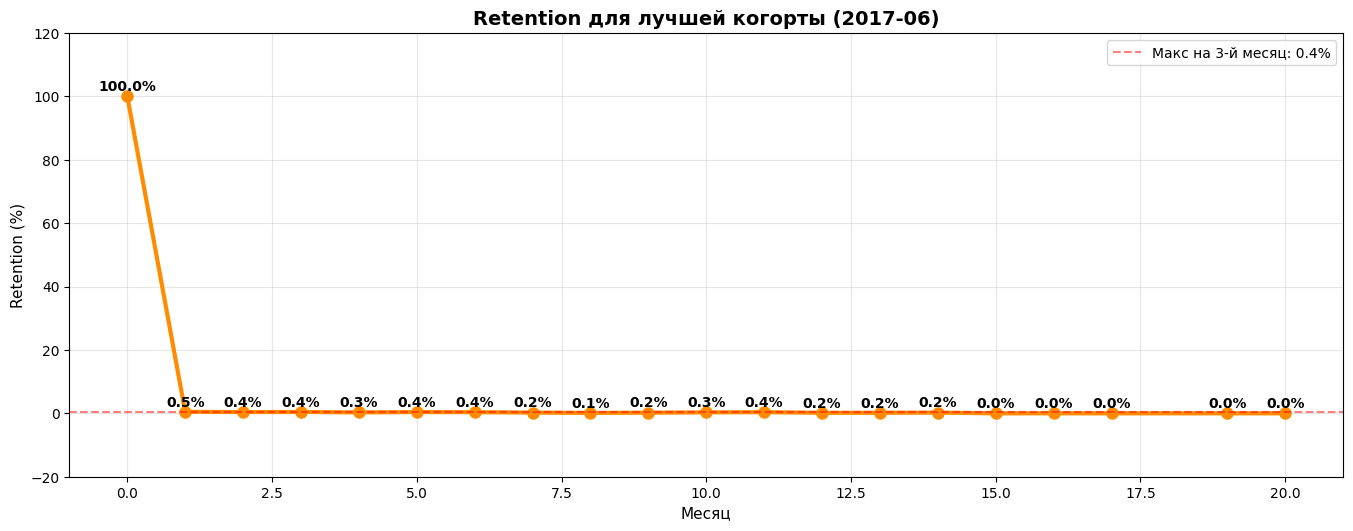

In [15]:
# сначала обозначим лучшую когорту с самым высоким retention на 3-й месяц
if 3 in cohort_retention.columns and not cohort_retention[3].dropna().empty:
    best = cohort_retention[3].dropna()
    best_cohort = best.idxmax()
    best_value = best.max()
    print(f"Когорта с самым высоким retention на 3-й месяц: {best_cohort} ({best_value:.2f}%)")

fig=plt.figure(figsize=(40, 10))
ax2=plt.subplot(2, 3, 3)

if best_cohort is not None:
    best_cohort_data = cohort_retention.loc[best_cohort].dropna()

    ax2.plot(best_cohort_data.index, best_cohort_data.values,
             marker='o', linewidth=3, markersize=8, color='darkorange')

    for x, y in zip(best_cohort_data.index, best_cohort_data.values):
        ax2.annotate(f'{y:.1f}%',
                    xy=(x, y),
                    xytext=(x, y + 0.8),
                    ha='center', va='bottom',
                    fontsize=10, fontweight='bold')

    ax2.set_title(f'Retention для лучшей когорты ({best_cohort})', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Месяц', fontsize=11)
    ax2.set_ylabel('Retention (%)', fontsize=11)
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=best_value, color='red', linestyle='--', alpha=0.5,
                label=f'Макс на 3-й месяц: {best_value:.1f}%')
    ax2.legend()
    ax2.margins(y=0.2)

plt.tight_layout()
plt.show()

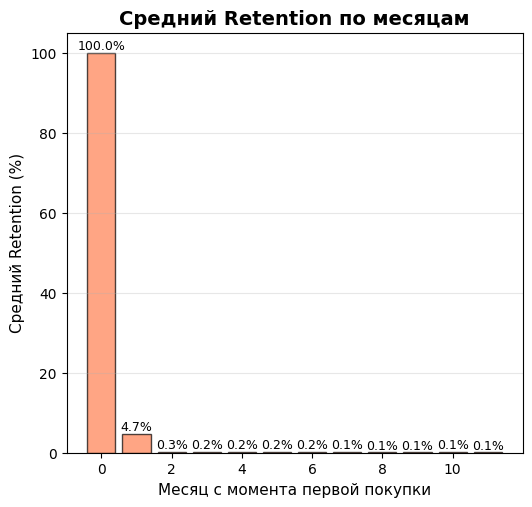

In [16]:
#динамика retention по месяцам (средние значения)

fig=plt.figure(figsize=(20, 12))
ax3=plt.subplot(2, 3, 5)
monthly_avg = cohort_retention.mean()
months_to_plot = monthly_avg.index[:12]  #первые 12 месяцев
avg_values = monthly_avg.values[:12]


bars = ax3.bar(months_to_plot, avg_values, color='coral', alpha=0.7, edgecolor='black')

for bar, val in zip(bars, avg_values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

ax3.set_title('Средний Retention по месяцам', fontsize=14, fontweight='bold')
ax3.set_xlabel('Месяц с момента первой покупки', fontsize=11)
ax3.set_ylabel('Средний Retention (%)', fontsize=11)
ax3.grid(True, alpha=0.3, axis='y')

Задача 2. Определить, существует ли product/market fit у маркетплейса.

Построив retention, вы решили оценить, насколько хорошо продукт закрывает потребности клиента.

Для этого вам нужно:

Определить, существует ли product/market fit у этого маркетплейса. Ведь до сих пор непонятно, можно ли масштабировать подобный продукт на новые рынки. Есть вероятность, что маркетплейс будет приносить убытки.

В рамках исследования необходимо:

Оценить наличие product/market fit у данного продукта с помощью когортного анализа, полученного на предыдущем шаге.
Пояснить свою позицию и сформулировать, на чём маркетплейс должен сконцентрироваться в ближайшее время. Если PMF есть, то в какую сторону лучше развивать продукт дальше? Если PMF нет, то какие причины могут быть у этого?
Подкрепить свои выводы релевантной визуализацией, удобной для восприятия.

In [17]:
mean_ret= cohort_retention.mean()
std_ret= cohort_retention.std()
median_month1= cohort_retention[1].median() if 1 in cohort_retention else None
print(mean_ret)
print(std_ret)
print(median_month1)

cohort_index
0     100.000000
1       4.740798
2       0.263741
3       0.185198
4       0.200554
5       0.150315
6       0.175673
7       0.120127
8       0.108086
9       0.091838
10      0.114840
11      0.100522
12      0.074663
13      0.068784
14      0.039788
15      0.048425
16      0.024054
17      0.048010
19      0.039253
20      0.033190
dtype: float64
cohort_index
0      0.000000
1     20.766906
2      0.158891
3      0.137944
4      0.157781
5      0.141705
6      0.153250
7      0.129144
8      0.118707
9      0.115082
10     0.143736
11     0.140102
12     0.155042
13     0.125716
14     0.072264
15     0.100325
16     0.064787
17     0.119859
19     0.160501
20     0.159171
dtype: float64
0.46363372935381053


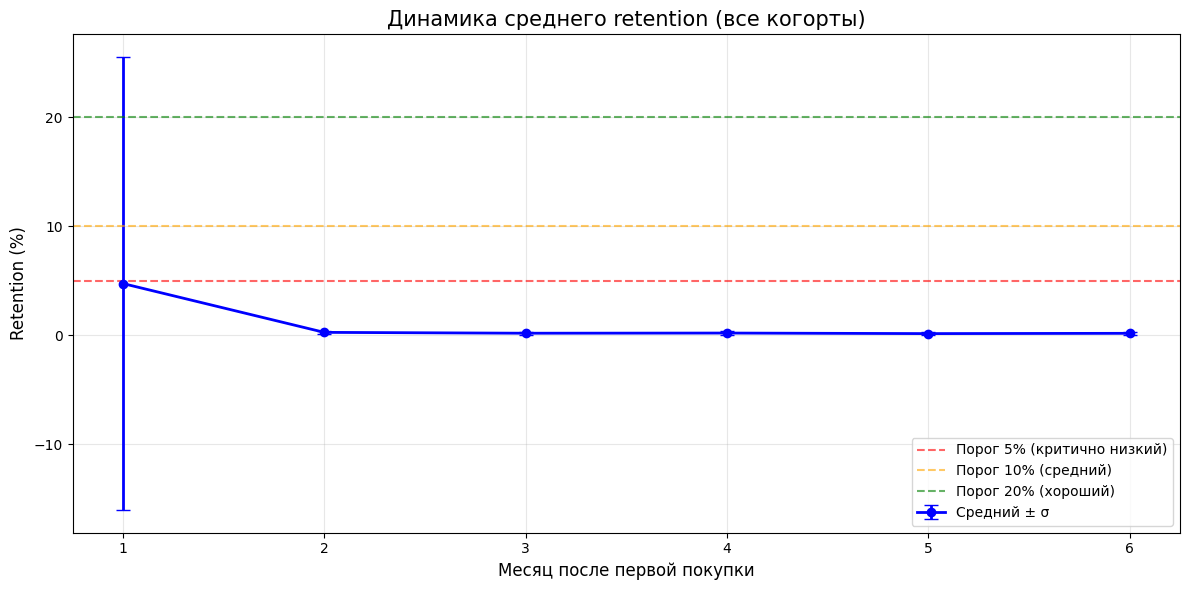

In [18]:
plt.figure(figsize=(12, 6))

months= range(1, 7)  # первые 6 месяцев
means= [mean_ret[m] for m in months if m in mean_ret]
stds= [std_ret[m]  for m in months if m in std_ret]

plt.errorbar(months, means, yerr=stds, marker='o', capsize=5,
             color='b', linestyle='-', linewidth=2, label='Средний ± σ')

# некоторые пороговые линии
plt.axhline(y=5, color='r', linestyle='--', alpha=0.6, label='Порог 5% (критично низкий)')
plt.axhline(y=10, color='orange', linestyle='--', alpha=0.6, label='Порог 10% (средний)')
plt.axhline(y=20, color='g', linestyle='--', alpha=0.6, label='Порог 20% (хороший)')
plt.title('Динамика среднего retention (все когорты)', fontsize=15)
plt.xlabel('Месяц после первой покупки', fontsize=12)
plt.ylabel('Retention (%)', fontsize=12)
plt.xticks(months)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


Для E-commerce retention:

30 дней: 20-30% —  может быть нормой.

90 дней: 10-15% —  также считается приемлемым.

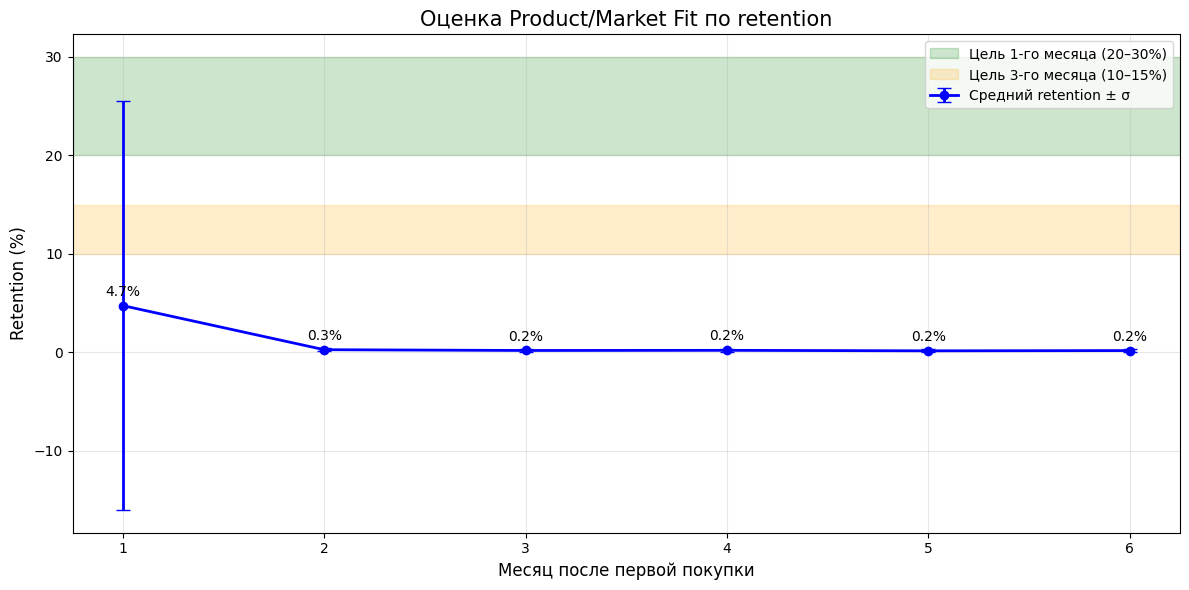

In [19]:
first= cohort_retention.index[0]
last= cohort_retention.index[-1]
best= cohort_retention[3].idxmax() if 3 in cohort_retention else first
ret_1 = cohort_retention[1].mean() if 1 in cohort_retention else None
ret_3 = cohort_retention[3].mean() if 3 in cohort_retention else None

pmf_status = ""
if ret_1 is not None and ret_3 is not None:
    if ret_1 >= 20 and ret_3 >= 10:
        pmf_status = "PMF достигнут"
    elif ret_1 >= 15 and ret_3 >= 8:
        pmf_status = "Требуется улучшение"
    else:
        pmf_status = "PMF не достигнут"

# график среднего retention с целевыми зонами
plt.figure(figsize=(12, 6))
months = list(range(1, 7))
means = [cohort_retention[m].mean() if m in cohort_retention else np.nan for m in months]
stds = [cohort_retention[m].std() if m in cohort_retention else np.nan for m in months] #доверительный интервал

plt.errorbar(months, means, yerr=stds, marker='o', capsize=5,
             color='b', linestyle='-', linewidth=2, label='Средний retention ± σ')

#целевые зоны
plt.axhspan(20, 30, alpha=0.2, color='green', label='Цель 1-го месяца (20–30%)')
plt.axhspan(10, 15, alpha=0.2, color='orange', label='Цель 3-го месяца (10–15%)')

for i, (m, r) in enumerate(zip(months, means)):
    if not np.isnan(r):
        plt.text(m, r + 1, f'{r:.1f}%', ha='center', fontsize=10)

plt.title('Оценка Product/Market Fit по retention', fontsize=15)
plt.xlabel('Месяц после первой покупки', fontsize=12)
plt.ylabel('Retention (%)', fontsize=12)
plt.xticks(months)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()



In [20]:
print(f"Статус: {pmf_status}")
print(f"\nФактические значения:")
if ret_1: print(f"  • Retention 1-го месяца: {ret_1:.1f}% (цель 20–30%)")
if ret_3: print(f"  • Retention 3-го месяца: {ret_3:.1f}% (цель 10–15%)")

Статус: PMF не достигнут

Фактические значения:
  • Retention 1-го месяца: 4.7% (цель 20–30%)
  • Retention 3-го месяца: 0.2% (цель 10–15%)


Retention значительно ниже целевых значений. Это указывает на то, что      клиенты не возвращаются за повторными покупками. Стоит сконцентрироваться на удержании и чаще проводить опросы клиентов. Возможные причины:

Товары не соответствуют ожиданиям

 Проблемы с доставкой или качеством  

  Отсутствие программ лояльности и коммуникации
  
  Слабый ассортимент для повторных заказов

Задача 3. Определить 5 основных метрик, на которых продакт может сконцентрироваться, чтобы максимизировать прибыль компании.

Вы разобрались с наличием product/market fit. Теперь вас просят сформулировать продуктовые метрики маркетплейса, чтобы компания могла на них ориентироваться.

В первую очередь необходимо:

Определить 5 основных метрик, на которых продакт может сконцентрироваться, чтобы максимизировать прибыль компании.

Первая метрика должна отражать рост объёма продаж маркетплейса.
Вторая — показывать объем аудитории, которой продукт доставляет ценность.
Третья — отражать заинтересованность новых клиентов в продукте (даже если вы не можете посчитать ее на имеющихся у вас данных).
Четвёртая — отражать вовлеченность клиента в продолжение использования продукта.
Пятая — отражать денежное выражение вовлеченности клиента.
Визуализируйте первую, вторую, четвёртую и пятую метрики. Используйте месячную гранулярность и окно в 1 месяц, если это нужно.

In [21]:
df_with_prices = pd.merge(df_delivered, oi[['order_id', 'price']], on='order_id', how='left')
df_with_prices['month'] = df_with_prices['order_purchase_timestamp'].dt.to_period('M')
df_delivered['month'] = df_delivered['order_purchase_timestamp'].dt.to_period('M')
df_with_prices.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,price,month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,29.99,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,118.70,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,159.90,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,45.00,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,19.90,2018-02


Метрика 1: Рост объема продаж (GMV - Gross Merchandise Value)

In [22]:
monthly_gmv=df_with_prices.groupby('month')['price'].sum().reset_index()
monthly_gmv.columns = ['month', 'gmv']
monthly_gmv['gmv_millions'] = monthly_gmv['gmv']/1000000
monthly_gmv.head()

,month,gmv,gmv_millions
0,2016-09,134.97,0.000135
1,2016-10,40325.11,0.040325
2,2016-12,10.90,0.000011
3,2017-01,111798.36,0.111798
4,2017-02,234223.40,0.234223


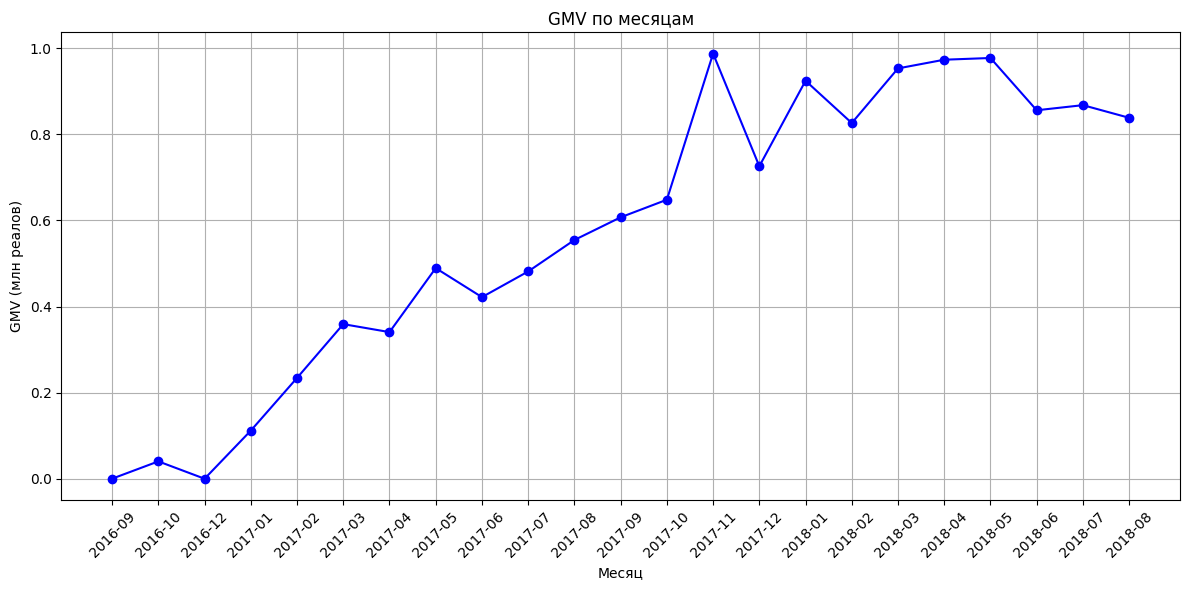

In [23]:
months = [str(m) for m in monthly_gmv['month']]
values = monthly_gmv['gmv_millions'].values

plt.figure(figsize=(12, 6))
plt.plot(months, values, 'bo-')
plt.title('GMV по месяцам')
plt.xlabel('Месяц')
plt.ylabel('GMV (млн реалов)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

Метрика 2: Количество активных покупателей

In [24]:
monthly_active_customers=df_delivered.groupby('month')['customer_unique_id'].nunique().reset_index()
monthly_active_customers.column=['month','active_customers']
monthly_active_customers.head()


/tmp/ipykernel_42990/2284846749.py:2: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  monthly_active_customers.column=['month','active_customers']


,month,customer_unique_id
0,2016-09,1
1,2016-10,262
2,2016-12,1
3,2017-01,718
4,2017-02,1630


 Метрика 3: Conversion Rate (заинтересованность новых клиентов)

In [25]:
monthly_active_customers = df_delivered.groupby('month')['customer_unique_id'].nunique().reset_index()
monthly_active_customers.columns = ['month', 'active_customers']


first_purch_month = df_delivered.groupby('customer_unique_id')['month'].min().reset_index()
first_purch_month.columns = ['customer_unique_id', 'first_month']
new_customers_by_month = first_purch_month.groupby('first_month').size().reset_index()
new_customers_by_month.columns = ['month', 'new_customers']
#в объединении с активными клиентами
monthly_metrics = pd.merge(monthly_active_customers, new_customers_by_month, on='month', how='left')
monthly_metrics['new_customers_share'] = (monthly_metrics['new_customers'] / monthly_metrics['active_customers'] * 100).round(1)
monthly_metrics.head(10)

,month,active_customers,new_customers,new_customers_share
0,2016-09,1,1,100.0
1,2016-10,262,262,100.0
2,2016-12,1,1,100.0
3,2017-01,718,717,99.9
4,2017-02,1630,1628,99.9
5,2017-03,2508,2503,99.8
6,2017-04,2274,2256,99.2
7,2017-05,3479,3451,99.2
8,2017-06,3076,3037,98.7
9,2017-07,3802,3752,98.7


Метрика 4: Retention Rate

In [26]:
retention_month1 = cohort_retention[1].mean() if 1 in cohort_retention.columns else 0

retention_by_month = [] # рассчитаем retention для каждой когорты
for month in sorted(cohort_retention.index):
    if month in cohort_retention.index and 1 in cohort_retention.columns:
        retention_by_month.append({
            'month': month,
            'retention_month1': cohort_retention.loc[month, 1] if 1 in cohort_retention.columns else 0
        })
retention_df = pd.DataFrame(retention_by_month)
retention_df.head()

,month,retention_month1
0,2016-09,0.000000
1,2016-10,0.000000
2,2016-12,100.000000
3,2017-01,0.278940
4,2017-02,0.184275


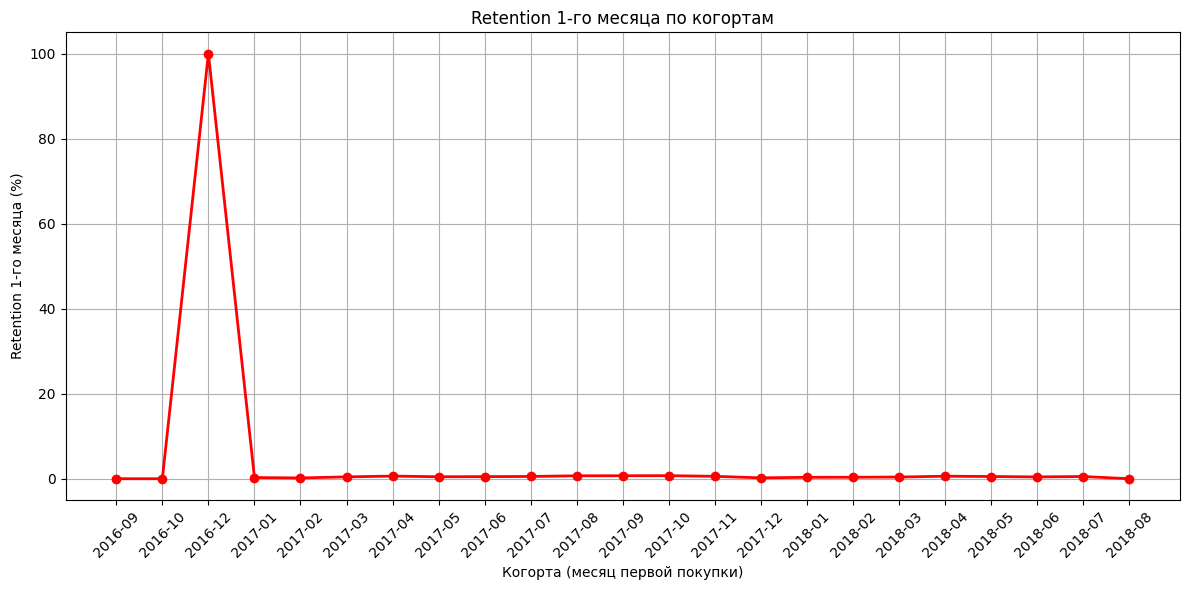

In [27]:
retention_series = cohort_retention[1].dropna()
months = [str(m) for m in retention_series.index]
values = retention_series.values

plt.figure(figsize=(12, 6))
plt.plot(months, values, 'ro-', linewidth=2, markersize=6)
plt.title('Retention 1-го месяца по когортам')
plt.xlabel('Когорта (месяц первой покупки)')
plt.ylabel('Retention 1-го месяца (%)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

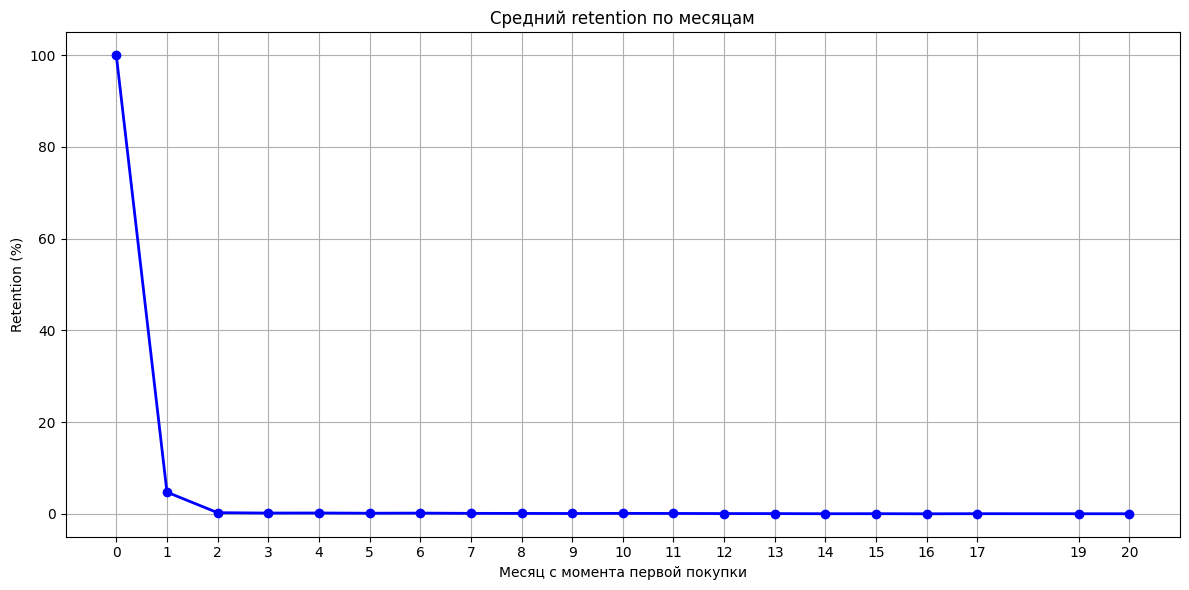

Средний retention по месяцам:
Месяц 0: 100.00%
Месяц 1: 4.74%
Месяц 2: 0.26%
Месяц 3: 0.19%
Месяц 4: 0.20%
Месяц 5: 0.15%
Месяц 6: 0.18%
Месяц 7: 0.12%
Месяц 8: 0.11%
Месяц 9: 0.09%
Месяц 10: 0.11%
Месяц 11: 0.10%
Месяц 12: 0.07%
Месяц 13: 0.07%
Месяц 14: 0.04%
Месяц 15: 0.05%
Месяц 16: 0.02%
Месяц 17: 0.05%
Месяц 19: 0.04%
Месяц 20: 0.03%


In [28]:
# График для retention по всем месяцам (средние значения по всем когортам)
avg_retention = cohort_retention.mean()
months = avg_retention.index
values = avg_retention.values

plt.figure(figsize=(12, 6))
plt.plot(months, values, 'bo-', linewidth=2, markersize=6)
plt.title('Средний retention по месяцам')
plt.xlabel('Месяц с момента первой покупки')
plt.ylabel('Retention (%)')
plt.xticks(months)
plt.grid(True)
plt.tight_layout()
plt.show()

print("Средний retention по месяцам:")
for month, value in zip(months, values):
    print(f"Месяц {month}: {value:.2f}%")

Метрика 5: LTV - Lifetime Value клиента


In [29]:
# Считаю LTV как средний чек * среднее количество заказов на клиента
avg_order_value = df_with_prices.groupby('order_id')['price'].sum().mean()
avg_orders_per_customer = df_delivered.groupby('customer_unique_id')['order_id'].nunique().mean()
ltv = avg_order_value * avg_orders_per_customer

#Помесячный LTV (пригодится для визуализации)
monthly_ltv = []
for month in monthly_gmv['month']:
    new_in_month = first_purch_month[first_purch_month['first_month'] == month]['customer_unique_id'].tolist()     #Клиенты, которые впервые пришли в этом месяце

    if len(new_in_month) > 0:
        #их покупки за все время
        customer_orders = df_delivered[df_delivered['customer_unique_id'].isin(new_in_month)]
        customer_value = pd.merge(customer_orders, oi[['order_id', 'price']], on='order_id', how='left')['price'].sum()
        avg_ltv = customer_value / len(new_in_month)
    else:
        avg_ltv = 0

    monthly_ltv.append({'month': month, 'ltv': avg_ltv})

ltv_df = pd.DataFrame(monthly_ltv)
ltv_df.head()

,month,ltv
0,2016-09,134.970000
1,2016-10,159.437290
2,2016-12,21.800000
3,2017-01,159.827671
4,2017-02,147.290209


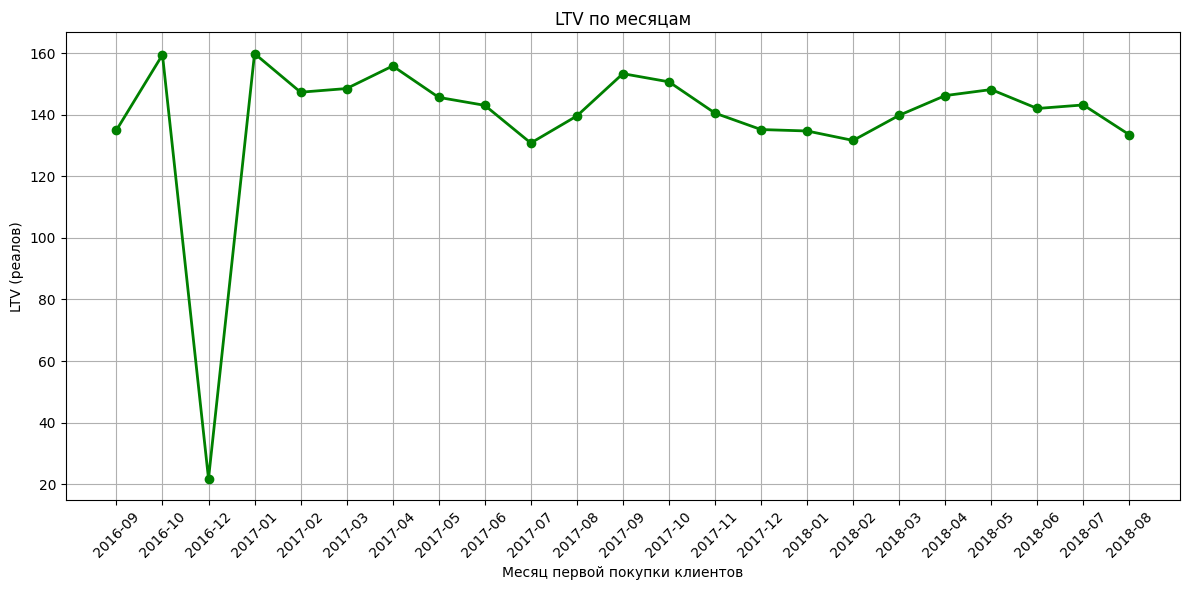

Средний LTV: 138.49 реалов
Минимальный LTV: 21.80 реалов
Максимальный LTV: 159.83 реалов


In [30]:
months = [str(m) for m in ltv_df['month']]
values = ltv_df['ltv'].values

plt.figure(figsize=(12, 6))
plt.plot(months, values, 'go-', linewidth=2, markersize=6)
plt.title('LTV по месяцам')
plt.xlabel('Месяц первой покупки клиентов')
plt.ylabel('LTV (реалов)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Средний LTV: {values.mean():.2f} реалов")
print(f"Минимальный LTV: {values.min():.2f} реалов")
print(f"Максимальный LTV: {values.max():.2f} реалов")

Задача 4. Выбрать одну из 3 основных гипотез с помощью фреймворка ICE.

Посмотрев с продактом на когортный анализ и метрики, вы решили, что нужно изменить продукт. Метрики необходимо срочно повышать. Вместе с командой вы сформулировали 3 гипотезы, в которые вы верите. По каждой гипотезе команда заполнила показатели по Ease, Confidence. Вам нужно заполнить самый важный показатель — Impact. Для этого вам требуется:

Выбрать одну из трёх основных гипотез с помощью фреймворка ICE, которые были сформированы продактом и, кажется, должны улучшить пользовательский опыт в маркетплейсе.

Для расчёта Impact возьмите данные с июня 2017 года. Считайте, что конверсия в повторный заказ равна величине медианного retention 1-го месяца (см. пункт 1 проекта).

In [31]:
# данные с июня 2017
df_2017=df_delivered[df_delivered['order_purchase_timestamp']>='2017-06-01'].copy()
median_retention_month1 = 4.7   #из задачи 1
repeat_conversion=median_retention_month1/100

In [32]:
# перевод количества заказов в Impact по шкале
def calculate_impact(additional_orders):
    if additional_orders <= 50:
        return 1
    elif additional_orders <= 150:
        return 2
    elif additional_orders <= 350:
        return 3
    elif additional_orders <= 750:
        return 4
    elif additional_orders <= 1550:
        return 5
    elif additional_orders <= 3150:
        return 6
    elif additional_orders <= 6350:
        return 7
    elif additional_orders <= 12750:
        return 8
    elif additional_orders <= 25550:
        return 9
    else:
        return 10


Гипотеза 1

Если исправим баг в системе процессинга заказов, то клиентам не придётся сталкиваться с проблемой отмены заказа, вследствие чего количество доставленных заказов увеличится. Считаем, что мы таким образом избавимся от всех отмен.

In [33]:
#Считаем количество отмененных заказов с июня 2017
canceled_orders = df_o_c[
    (df_o_c['order_purchase_timestamp'] >= '2017-06-01') &
    (df_o_c['order_status'].isin(['canceled', 'unavailable']))].shape[0]
print(f"Отмененных заказов с июня 2017: {canceled_orders}")

# Каждый отмененный заказ мог бы стать доставленным и некоторые из этих клиентов могли бы сделать повторный заказ
additional_orders_h1 = canceled_orders*(1+repeat_conversion)
print(f"Дополнительных заказов (гипотеза 1): {additional_orders_h1:.0f}")

Отмененных заказов с июня 2017: 974
Дополнительных заказов (гипотеза 1): 1020


Гbпотеза 2

Если сократим время до отгрузки заказа, то клиенты перестанут получать свой заказ с запаздыванием, вследствие чего количество заказов увеличится за счёт повторных заказов.

In [34]:
#Считаем количество заказов с задержкой (доставлено позже обещанного)
delayed_orders = df_delivered[
    (df_delivered['order_purchase_timestamp'] >= '2017-06-01') &
    (df_delivered['order_delivered_customer_date'] > df_delivered['order_estimated_delivery_date'])].shape[0]
print(f"Заказов с задержкой с июня 2017: {delayed_orders}")

#Если улучшим доставку, то эти клиенты еще могут вернуться
additional_orders_h2 = delayed_orders * repeat_conversion
print(f"Дополнительных заказов (гипотеза 2): {additional_orders_h2:.0f}")

Заказов с задержкой с июня 2017: 7295
Дополнительных заказов (гипотеза 2): 343


Гипотеза 3

Если создадим новый способ оплаты, который будет конвертировать клиентов в повторный заказ, то клиенты не будут испытывать трудности при оформлении заказа, вследствие чего количество заказов увеличится за счёт повторных заказов тех, кто раньше не делал повторный заказ.

In [35]:
# Смотрим заказы с проблемами оплаты
#
df_2017 = df_delivered[df_delivered['order_purchase_timestamp'] >= '2017-06-01'].copy()
df_all_2017 = df_o_c[df_o_c['order_purchase_timestamp'] >= '2017-06-01'].copy()

payment_issues = df_all_2017[df_all_2017['order_status'].isin([
    'canceled',           # отменен (возможно, из-за оплаты)
    'unavailable'       ])].copy()   # недоступен (возможно, не оплатили)

print(f"Заказов с проблемами (отмены): {len(payment_issues)}")

#сколько уникальных клиентов столкнулись с проблемами
customers_with_issues = payment_issues['customer_unique_id'].nunique()
print(f"Уникальных клиентов с проблемами: {customers_with_issues}")

# Из них сколько сделали успешный заказ позже? Т.е. проблема была временной, и они все-таки купили
customers_with_issues_success = []
for cust in payment_issues['customer_unique_id'].unique():
    #Есть ли у этого клиента доставленные заказы после проблемы?
    problem_date = payment_issues[payment_issues['customer_unique_id']==cust]['order_purchase_timestamp'].min()
    later_orders = df_delivered[
        (df_delivered['customer_unique_id'] == cust) &
        (df_delivered['order_purchase_timestamp'] > problem_date)]
    if len(later_orders) > 0:
        customers_with_issues_success.append(cust)

print(f"Клиентов, которые решили проблему и купили позже: {len(customers_with_issues_success)}")

# клиенты, которые ушли совсем из-за проблем с оплатой
lost_customers = customers_with_issues - len(customers_with_issues_success)
print(f"Клиентов, потерянных из-за проблем с оплатой: {lost_customers}")

# Каждый потерянный клиент мог бы сделать repeat_conversion повторных заказов
additional_orders_h3 = lost_customers*(1+repeat_conversion)
print(f"Дополнительных заказов (гипотеза 3): {additional_orders_h3:.0f}")


Заказов с проблемами (отмены): 974
Уникальных клиентов с проблемами: 960
Клиентов, которые решили проблему и купили позже: 37
Клиентов, потерянных из-за проблем с оплатой: 923
Дополнительных заказов (гипотеза 3): 966


In [36]:
# Impact для каждой гипотезы
impact_h1= calculate_impact(additional_orders_h1)
impact_h2= calculate_impact(additional_orders_h2)
impact_h3= calculate_impact(additional_orders_h3)

print(f"\nImpact гипотезы 1: {impact_h1}")
print(f"Impact гипотезы 2: {impact_h2}")
print(f"Impact гипотезы 3: {impact_h3}")


Impact гипотезы 1: 5
Impact гипотезы 2: 3
Impact гипотезы 3: 5


In [37]:
hypotheses = pd.DataFrame({
    'Гипотеза': [
        '1',
        '2',
        '3'  ],
    'Impact': [impact_h1, impact_h2, impact_h3],
    'Confidence': [8, 10, 5],
    'Ease': [6, 4, 9]})

#  ICE = (Impact * Confidence) *Ease
hypotheses['ICE'] = (hypotheses['Impact'] * hypotheses['Confidence']) * hypotheses['Ease']
hypotheses['ICE'] = hypotheses['ICE'].round(2)
hypotheses_sorted = hypotheses.sort_values('ICE', ascending=False)


print(hypotheses_sorted.to_string(index=False))

#Выбор лучшей гипотезы
best_hypothesis = hypotheses_sorted.iloc[0]
print(f"Лучшая гипотеза: {best_hypothesis['Гипотеза']}")


Гипотеза  Impact  Confidence  Ease  ICE
       1       5           8     6  240
       3       5           5     9  225
       2       3          10     4  120
Лучшая гипотеза: 1


Задача 5. Сформулировать нужные метрики, на которые ваша гипотеза должна повлиять.

После предыдущего исследования у вас появилась гипотеза, которую можно реализовать для значительного улучшения метрик компании. Вы предложили использовать A/B-тестирование для проверки её эффективности.

Продакт попросил вас:

Сформулировать метрики, на которые должна повлиять выбранная вами гипотеза.
Сформулировать хотя бы по одной метрике в категории: целевые, прокси, guardrail и объяснить свой выбор.

Гипотеза - Если исправим баг в системе процессинга заказов, то клиентам не придётся сталкиваться с проблемой отмены заказа, вследствие чего количество доставленных заказов увеличится. Считаем, что мы таким образом избавимся от всех отмен.

 --------------------------------------
 Целевая метрика

 Гипотеза направлена на увеличение числа успешно завершённых заказов за счёт устранения отмен. Если баг исправлен, пользователи, которые раньше сталкивались с отменой, теперь смогут оформить заказ и, возможно, совершить повторные покупки. Тогда метрика "Среднее количество доставленных заказов на пользователя" напрямую отражает итоговый эффект.

 -------------------------------------------------------
Прокси-метрика


Доля отменённых заказов (Cancel Rate)

 Если баг действительно устранён, процент отмен должен бфстро снизиться в экспериментальной группе. Её можно измерять на ранних этапах теста, не дожидаясь накопления данных по повторным заказам.

 ----------------------------------------------------
  Guardrail-метрика

Среднее время от создания заказа до подтверждения (в часах)

 Исправление бага не должно замедлять обработку заказов. Если новое решение случайно внесёт задержки, например, из-за доп. проверок, это негативно скажется на опыте пользователей. Данная метрика позволит убедиться, что скорость обработки заказов не ухудшилась.

Задача 6.


Сформулируйте выводы о проделанной работе и подготовьте небольшой, но логичный и содержательный отчет для Пети.




**формализация проблемы продукта: что не так и как вы это поняли?**

Выручка маркетплейса перестала расти и стоит на месте уже несколько месяцев. При первичном анализе данных мы обнаружили ключевую причину: клиенты практически не возвращаются после первой покупки.


Мы провели когортный анализ retention (задача 1) и получили следующие результаты:
- Медианный retention 1-го месяца составляет всего 4.7% (при бенчмарках e-commerce 20–30%)
- Retention 3-го месяца — 0.2% (тогда как целевые 10–15%).
- Лучшая когорта на 3-й месяц показала значение лишь около 1–2%, что подтверждает системную проблему удержания.

Это означает, что маркетплейс работает как «воронка с дырявым дном»: мы тратим ресурсы на привлечение новых клиентов, но они не задерживаются, рост выручки прекращается очень быстро.

**общие выводы по итогу исследования на основе результатов, полученных в заданиях 1-5**

 Клиенты не возвращаются, необходимы были срочные меры по удержанию. PMF не был достигнут, Retention значительно ниже целевых ориентиров (20%+ на 1-й месяц). Это говорит о том, что продукт  не закрывал ключевые потребности клиентов, и масштабирование без улучшения удержания приводило к убыткам.

 Определили следующие метрики:
1. **GMV (объём продаж)** – показывает рост выручки. За последний месяц GMV составил чуть более 0.8 млн реалов.
2. **Активные покупатели** – размер аудитории.
3. **Доля новых клиентов**
4. **Retention 1-го месяца** – вовлеченность (4.7%).
5. **LTV** – монетизация. Средний LTV 138.49 реалов, что крайне мало для e-commerce.


Лучшим решением оказалось исправление бага, эта гипотеза (№1) обещает наибольший эффект.

Для проверки гипотезы предлагаем следующие метрики:
- **Целевая:** среднее количество доставленных заказов на пользователя (или общая выручка) – покажет итоговый бизнес-эффект.
- **Прокси:** доля отменённых заказов (cancel rate) – быстро отреагирует на изменение и подтвердит устранение бага.
- **Guardrail:** среднее время от создания заказа до подтверждения (в часах) – так мы убедимся, что скорость обработки заказов не ухудшилась.

**Рекомендации по продукту**

1. Первым делом внедрить исправление бага в обработке заказов. Ожидаем снижения доли отмен и увеличения числа доставленных заказов и повторных покупок.
2. Запустить A/B-тест для контроля влияния изменений на указанные метрики.
3. Масштабирование отложить до достижения retention 1-го месяца не менее 10–15% – пока продукт не готов к привлечению новых клиентов.
4. Параллельно дополнительно работать над улучшением retention:
- Внедрить ремаркетинг.
- Разработать программу лояльности для стимулирования повторных заказов.
- Провести качественные исследования  среди клиентов, совершивших только одну покупку, чтобы выявить истинные причины оттока.